In [18]:
!pip install biopython

In [23]:
from Bio.Seq import Seq
my_seq=Seq("AGCTAGCTAGCTU")
for i,I in enumerate(my_seq):
  print(f"{i}:{I}")
print(f"length:{len(my_seq)}")  

0:A
1:G
2:C
3:T
4:A
5:G
6:C
7:T
8:A
9:G
10:C
11:T
12:U
length:13


In [24]:
u_percent=my_seq.count("U")/len(my_seq)*100
print("U percent in seq:",u_percent)

U percent in seq: 7.6923076923076925


In [25]:
from  Bio.SeqUtils import gc_fraction
gc_fraction(my_seq)

0.46153846153846156

In [26]:
#slicing
my_seq[2:4]

Seq('CT')

In [29]:
#concat
myseq1=Seq("ACUGU")
myseq2=Seq("UCGG")
myseq1+myseq2

Seq('ACUGUUCGG')

In [31]:
#list of seq concat
list_seq=[Seq("ABU"),Seq("UBC"),Seq("UYT")]
final_seq=Seq("")
for s in list_seq:
  final_seq+=s
print(final_seq)  

ABUUBCUYT


In [33]:
#complement
print(my_seq)
print(my_seq.complement())
print(my_seq.reverse_complement())

AGCTAGCTAGCTU
TCGATCGATCGAA
AAGCTAGCTAGCT


In [36]:
#can't change  immutable
my_seq[2]="T"

TypeError: 'Seq' object does not support item assignment

In [ ]:
#mutable seq
from Bio.Seq import MutableSeq
mutable_seq=MutableSeq("AGCTAGCTAGCTU")
print(f"muable:",mutable_seq)

muable AGCTAGCTAGCTU


In [38]:
mutable_seq[2]="T"
print(mutable_seq)

AGTTAGCTAGCTU


In [ ]:
#find subsequence
print(my_seq.index("CTU"))#index  if seq is not there give error
print(my_seq.find("CTUO"))#if not then give -1

10
-1


In [43]:
#search
for index,sub in my_seq.search(["AG","TA"]):
  print(index,sub)

0 AG
3 TA
4 AG
7 TA
8 AG


In [46]:
#seq_Record
my_seq1="AGCTAGCTAGCTU"
from Bio.SeqRecord import SeqRecord
# Create a Seq object first
my_sequence = Seq("ATGCAGTAG")

# Create a SeqRecord object
record = SeqRecord(
    my_sequence,
    id="NC_005816",
    name="gi|1234567|gb|ABC1234.1|",
    description="Example protein sequence",
    annotations={"molecule_type": "DNA"}
)

In [49]:
record.description

'Example protein sequence'

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import Entrez
from Bio import SeqIO

In [56]:
#download influnza
Entrez.email="shivamcse2k21@gmail.com"

handle = Entrez.efetch(
    db="nucleotide",
    id="CY121680",
    rettype="fasta",
    retmode="text"
)

record = SeqIO.read(handle, "fasta")

print(record.description)


CY121680.1 Influenza A virus (A/California/07/2009(H1N1)) hemagglutinin (HA) gene, complete cds


In [58]:
print(len(record.seq))

1752


In [60]:
#gc fraction
gc_fraction(record.seq)*100

40.582191780821915

In [64]:
#feq
from collections import Counter
counts=Counter(record.seq)
print(counts)

Counter({'A': 628, 'T': 413, 'G': 387, 'C': 324})


<BarContainer object of 4 artists>

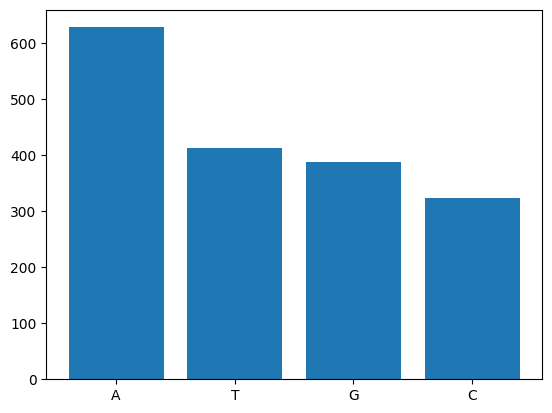

In [66]:
#print freq
bases = ['A', 'T', 'G', 'C']
values = [counts.get(base, 0) for base in bases]

plt.bar(bases,values)

In [ ]:
#k-mer analysis
